Analysation of the data coming from the simulator.

In [1]:
import numpy as np
import xarray as xr
import yaml
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from wireless_channel.subTHz_channel import Channel
from wireless_channel.waveforms import Waveform
from sub_THz_stripe.central_unit.central_unit import CentralUnit
from sub_THz_stripe.radio_unit.radio_unit import RadioUnit

In [2]:
# Read out the config file.
config_file = "examples/flickering/config.yml"
with open(config_file, "r", encoding="utf8") as file:
    config = yaml.safe_load(file)

In [3]:
# Construct the waveform class based on the loaded configuration.
waveform_config = config["waveform_config"]
freq_band_config = config["sub_thz"]
wf = Waveform.from_config(waveform_config, freq_band_config)

In [4]:
# Generate an CP-OFDM waveform in the time domain.
bits = wf.generate_bits()
qam = wf.qam_modulate()
ofdm_time = wf.ofdm_modulate()  # shape: nr_ofdm_symb x (fftsize + cp length)

# Thomas F. manier
pavg = np.mean(np.abs(ofdm_time) ** 2)
alpha = np.sqrt(0.01 / pavg)
ofdm_time = ofdm_time * alpha
pavg = 10 * np.log10(np.mean(np.abs(ofdm_time) ** 2) / 1e-3)

In [5]:
# The UE has the same hardware as a central unit.
ue = CentralUnit()  # todo are these configs loadable?
ofdm_time_after_ue = ue.run(ofdm_time)  # shape: nr_ofdm_symbols x (fft_size + cp length)

# A single radio unit is used to represent the transmit stage of the ue. The UE position does not influence the
# transmission so we can set it arbitrarily.
ue_ru = RadioUnit(x=0, y=0, z=0, wf=wf)

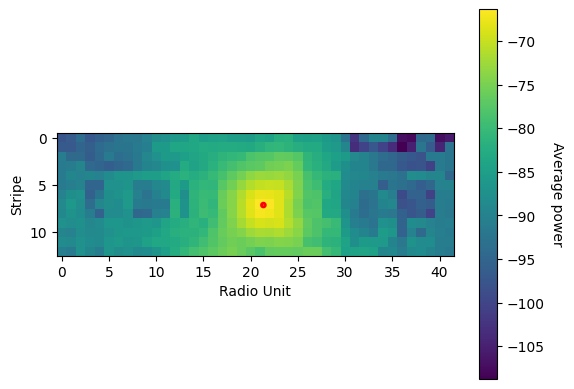

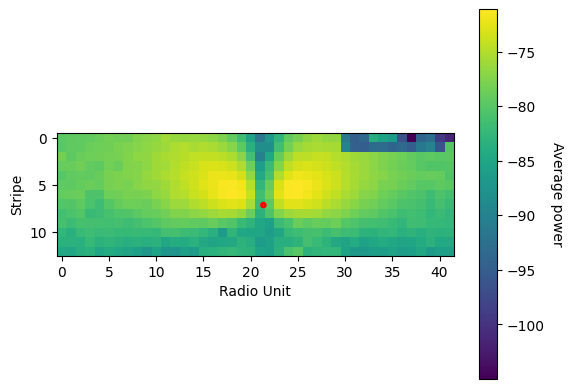

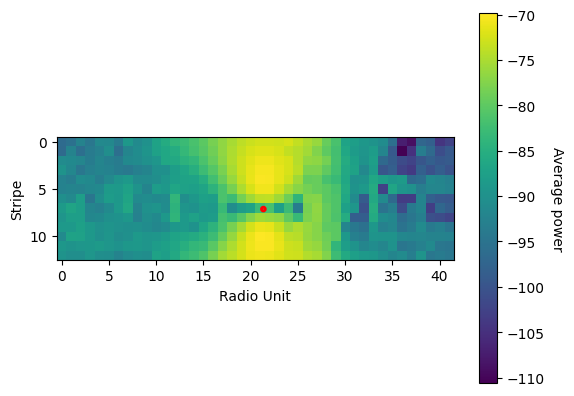

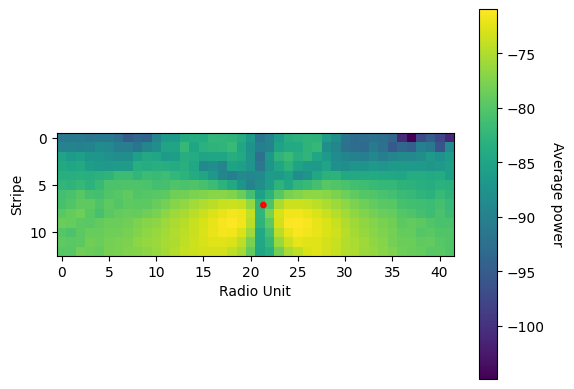

In [6]:
ue_ds = xr.load_dataset("configurations/ue_locations_5681.nc")

for ue_beam in range(4):
    ue_shift = ue_ru.phase_shifter.get_phases(ue_beam)
    iq_data_tx, imdata = ue_ru.transmit(ofdm_time_after_ue, ue_shift)

    for ue_pos in config["ue_positions"][:1]:
        channel = Channel.from_sionna(ue_pos, "ue_locations_5681.nc")
        # Transmit the data over the channel and get the data at all the radio units.
        iq_data_rx = channel.transmit_ul(iq_data_tx, wf)

        # Make a plot for every UE. The plot is a heatmap with the data for every stripe on the y-axis and the data for every
        # RU on the x-axis.
        fig, ax = plt.subplots()
        data = np.zeros((iq_data_rx.shape[0], iq_data_rx.shape[1]))
        for stripe_idx, stripe_data in enumerate(iq_data_rx):
            # Now iterate over all the data from the different RUs and calculate the pavg.
            for ru_idx, ru_data in enumerate(stripe_data):
                pavg = np.mean(np.abs(ru_data) ** 2)
                pavg = 10 * np.log10(pavg / 1e-3)

                data[stripe_idx, ru_idx] = pavg
            
        im = ax.imshow(data)
        circle = Circle(((ue_pos["y"]-2.5) * 2, (ue_pos["x"]-2.0) * 2), radius=0.2, edgecolor='red', facecolor='none', linewidth=2)
        ax.add_patch(circle)

        # Create colorbar
        cbar = ax.figure.colorbar(im, ax=ax)
        cbar.ax.set_ylabel("Average power", rotation=-90, va="bottom")

        ax.set_ylabel("Stripe")
        ax.set_xlabel("Radio Unit")